<a href="https://colab.research.google.com/github/jerrinojacob/Data-Science-Portfolio/blob/main/Project_06/CNN_Cats_and_Dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 6 - Cats and Dogs Classification - CNN

## Problem Definition


This project focuses on a supervised binary classification problem in computer vision, specifically distinguishing between images of cats and dogs. A Convolutional Neural Network (CNN) is employed as the deep learning architecture to automatically extract relevant features and perform classification. The model undergoes training on labeled data and is subsequently evaluated on novel images to validate its predictive accuracy. This work exemplifies the efficacy of deep learning techniques in automating feature extraction and addressing traditionally challenging image recognition tasks.



## Data Collection


#####Importing Packages

In [1]:
#Importing packages for computing
import pandas as pd
import numpy as np

#For ploting graphs
import matplotlib.pyplot as plt

#Serializing / De-serializing objects
import pickle

#HTTP requests
import requests

#TTS - divides dataset for Training and Testing
from sklearn.model_selection import train_test_split

#Importing the Keras Model
from keras.models import Sequential
from keras.layers import Flatten, Dense, Input, Conv2D, MaxPooling2D

from tensorflow.keras.utils import plot_model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model

#importing OpenCV - for computer vision and image processing tasks
import cv2

#####Loading AWS files for computation

In [2]:
url_X = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'
url_y = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'
url_dog = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg"

{'url_X':url_X, 'url_y':url_y, 'url_dog':url_dog}

{'url_X': 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle',
 'url_y': 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle',
 'url_dog': 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg'}

In [3]:
#Downloading  files from AWS
!curl -O {url_X}

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  237M  100  237M    0     0  13.6M      0  0:00:17  0:00:17 --:--:-- 15.9M


In [4]:
!curl -O {url_y}

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 49948  100 49948    0     0  59345      0 --:--:-- --:--:-- --:--:-- 59320


In [5]:
!curl -O {url_dog}

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 60603  100 60603    0     0  54826      0  0:00:01  0:00:01 --:--:-- 54844


#####Loading Pickled data

In [6]:
#HTTP GET request to AWS
response = requests.get(url_X)

#De-serialize the reponse from AWS
X = pickle.loads(response.content)

In [7]:
f"Shape of X: {X.shape}"

'Shape of X: (24946, 100, 100, 1)'

In [8]:
f"Number of images: {len(X)}"

'Number of images: 24946'

In [9]:
f"Dimensions of images: {X[0].shape}"

'Dimensions of images: (100, 100, 1)'

In [10]:
#HTTP GET request to AWS
response = requests.get(url_y)

#De-serialize the reponse from AWS
y = np.array(pd.read_pickle(url_y))

In [11]:
f"Shape of y: {y.shape}"

'Shape of y: (24946,)'

In [12]:
f"Number of images: {len(y)}"

'Number of images: 24946'

In [13]:
f"Number of classes: {len(np.unique(y))}"

'Number of classes: 2'

In [14]:
print(f"Class distribution:\n\t\tCats (0): {np.sum(y==0)},\n\t\tDogs (1): {np.sum(y==1)}")

Class distribution:
		Cats (0): 12470,
		Dogs (1): 12476


## Data Cleaning


In [15]:
#Normalizing pixel values 0-255 to 0-1 range
X = X / 255.0
X

array([[[[0.37254902],
         [0.36862745],
         [0.38431373],
         ...,
         [0.66666667],
         [0.6745098 ],
         [0.67058824]],

        [[0.36078431],
         [0.35686275],
         [0.37254902],
         ...,
         [0.66666667],
         [0.6745098 ],
         [0.67058824]],

        [[0.34901961],
         [0.35686275],
         [0.36078431],
         ...,
         [0.64705882],
         [0.6627451 ],
         [0.6627451 ]],

        ...,

        [[0.32941176],
         [0.29803922],
         [0.28627451],
         ...,
         [0.52941176],
         [0.64313725],
         [0.60392157]],

        [[0.32156863],
         [0.30980392],
         [0.27843137],
         ...,
         [0.55686275],
         [0.5254902 ],
         [0.6       ]],

        [[0.31372549],
         [0.33333333],
         [0.33333333],
         ...,
         [0.59215686],
         [0.57254902],
         [0.54117647]]],


       [[[0.67058824],
         [0.60392157],
         [0.54

## Exploratory Data Analysis


#####Shapes of the Data

In [16]:
#Shape of X - 4D
X.shape

(24946, 100, 100, 1)

In [17]:
f"Type of X: {type(X)}"

"Type of X: <class 'numpy.ndarray'>"

In [18]:
#Shape of y - 1D
y.shape

(24946,)

In [19]:
f"Type of X: {type(y)}"

"Type of X: <class 'numpy.ndarray'>"

#####Image Samples from Data

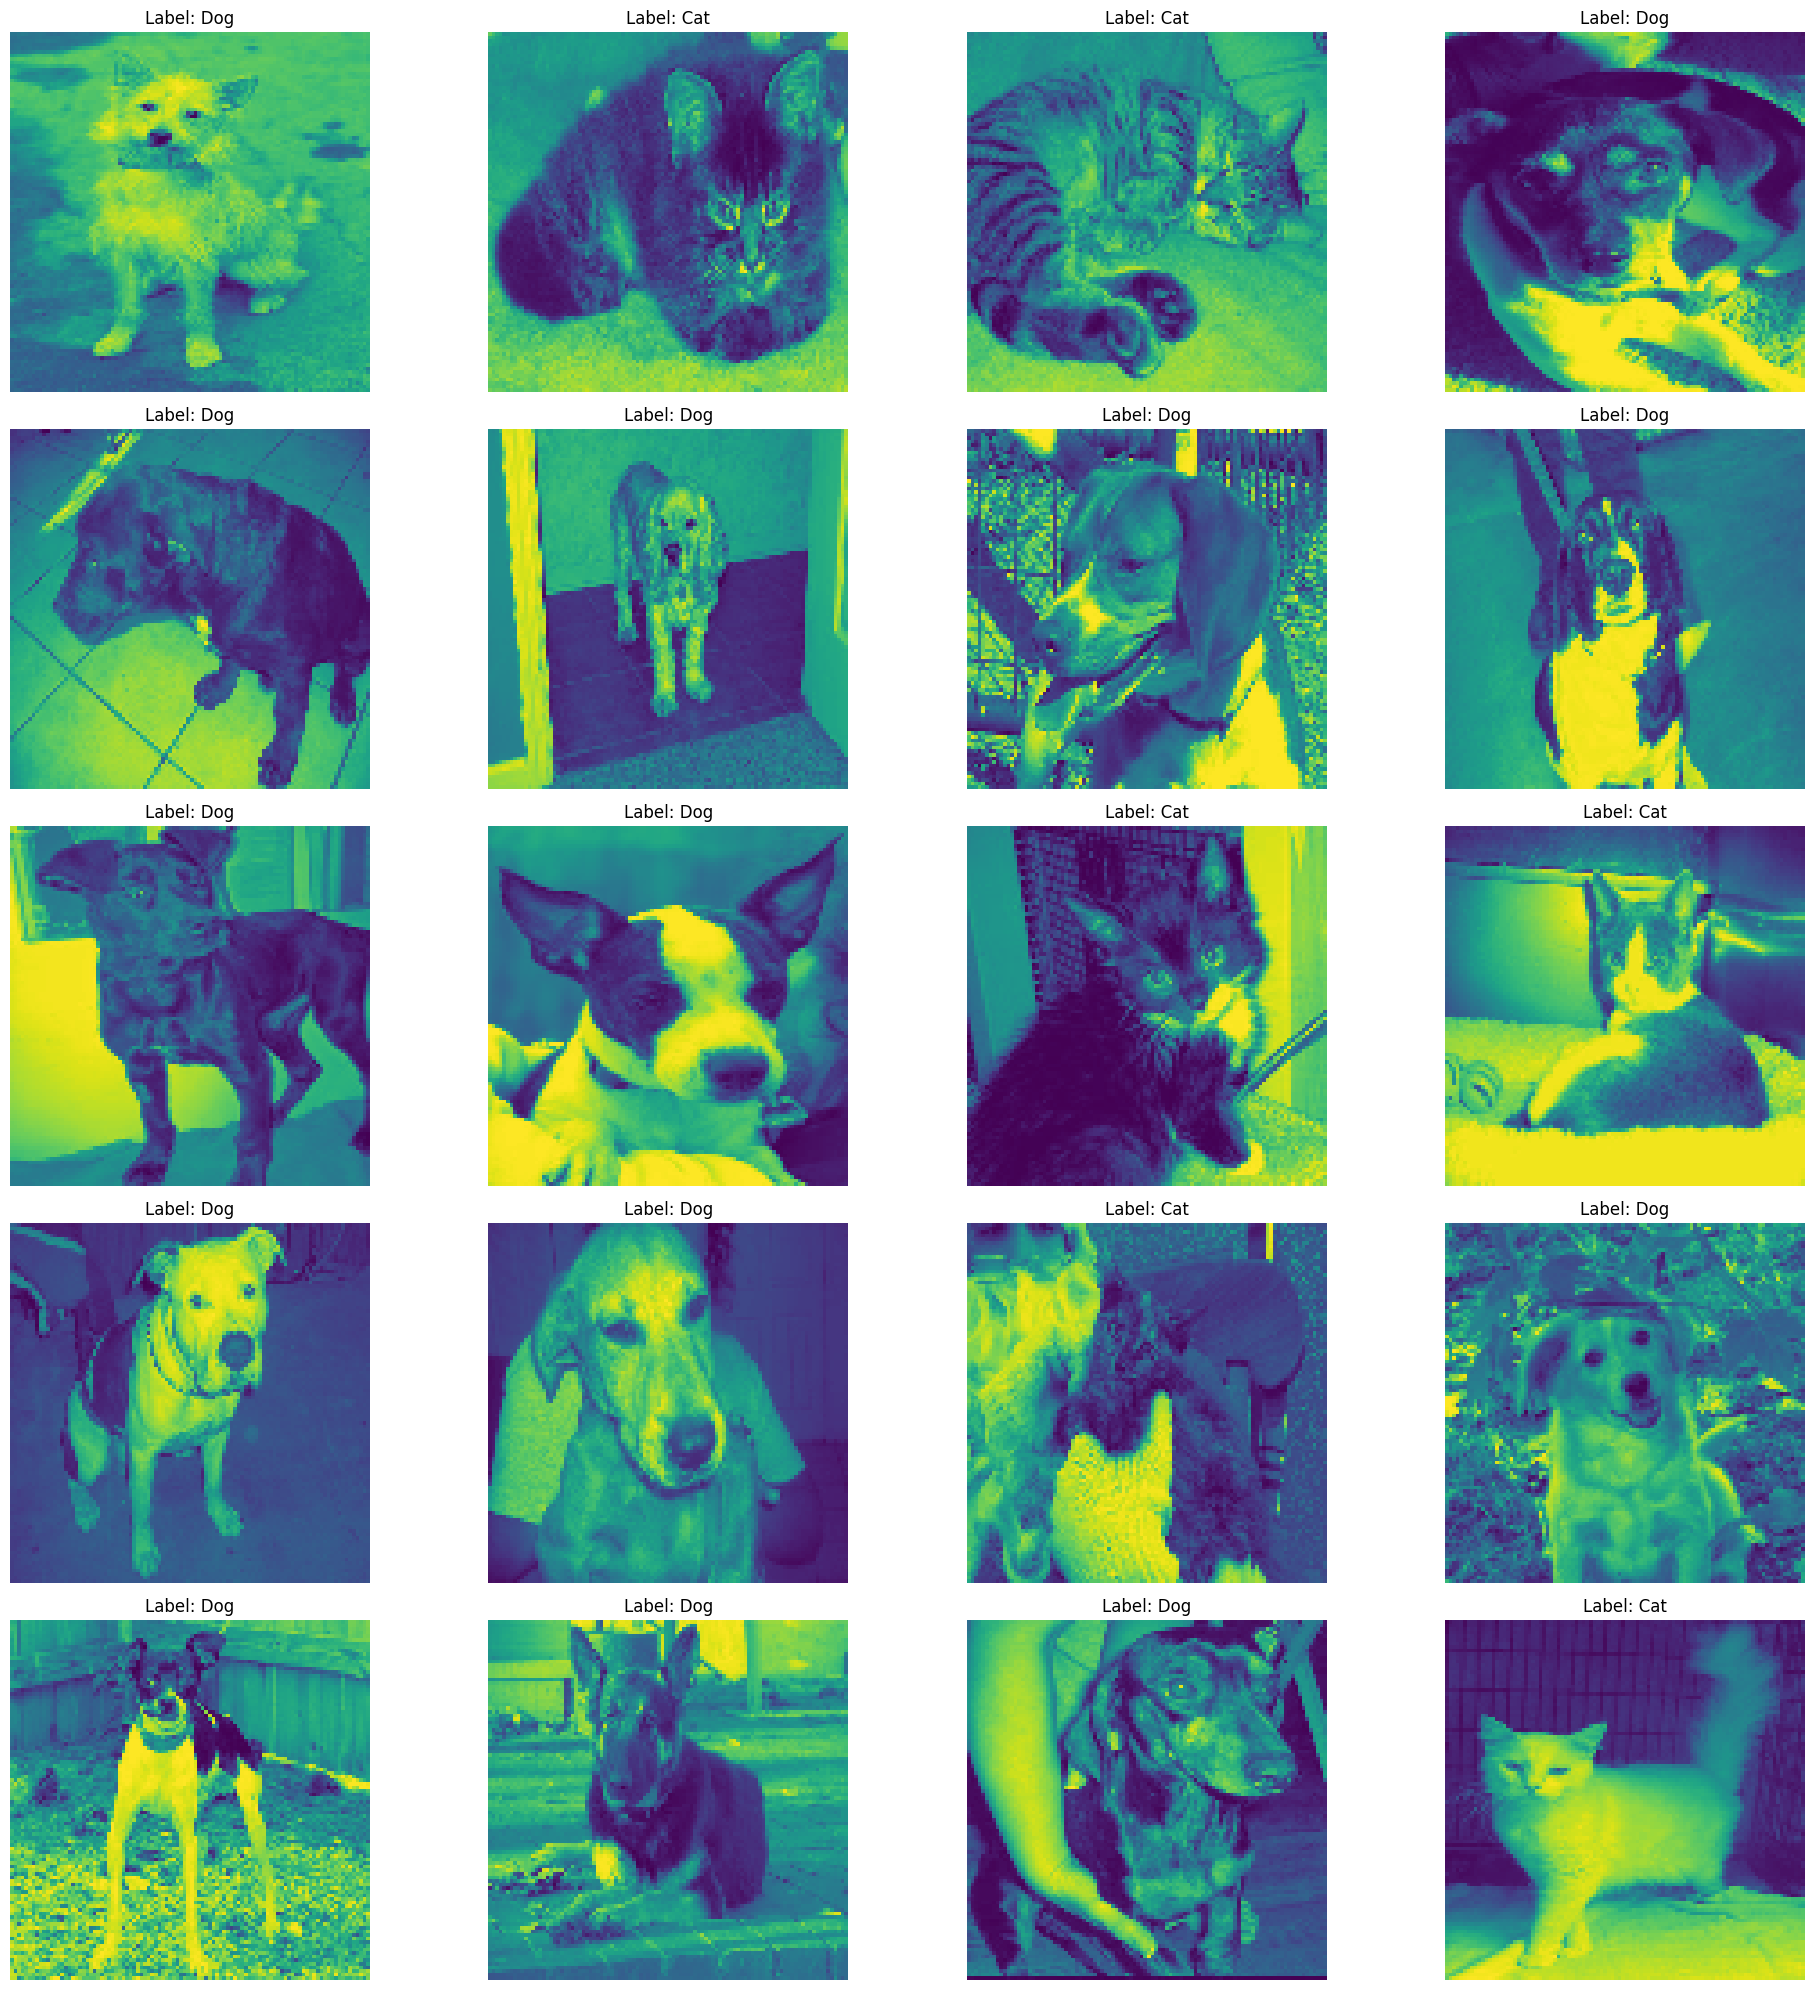

In [20]:
#Sample of 20 Images

fig, axes = plt.subplots(5, 4, figsize=(20,20))
axes = axes.ravel()

for i in range(20):
    axes[i].imshow(X[i])
    axes[i].set_title(f"Label: {'Dog' if y[i] == 0 else 'Cat'}")
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')

######Backing up data for test run

In [21]:
#Backup
X_sampling = X
y_sampling = y

In [22]:
#Restore
X = X_sampling
y = y_sampling

#####Setting Sample Data for test run

In [23]:
#Sampling with 10% of Data
sample_size = int(0.1 * len(X))
f'Selecting {sample_size} out of {len(X)}'

'Selecting 2494 out of 24946'

In [24]:
#Random indices from the sample size
random_index = np.random.choice(X.shape[0], size=sample_size, replace=False)
# random_index

In [25]:
#Sample Data
X = X[random_index]
y = y[random_index]

In [26]:
X.shape, y.shape

((2494, 100, 100, 1), (2494,))

## Data Processing


#####Train-Test-Split

In [27]:
#TTS
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
X_train.shape,y_train.shape,

((1995, 100, 100, 1), (1995,))

In [29]:
X_test.shape,y_test.shape,

((499, 100, 100, 1), (499,))

#####Building Model

In [30]:
model = Sequential()

In [31]:
# Define input layer
model.add(
  Input(
    shape=X_train.shape[1:],
    name="model_input",
  ),
)

In [32]:
# Define first hidden layers
model.add(
  Conv2D(
    name = "Conv1",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)

In [33]:
# Define second hidden layer
model.add(
  Conv2D(
    name = "Conv2",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
  MaxPooling2D(pool_size=(2,2))
)

In [34]:
# Define third hidden layer
model.add(
  Conv2D(
    name = "Conv3",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
  MaxPooling2D(pool_size=(2,2))
)

In [35]:
# Flatten input data into a 1D structure
model.add(
    Flatten()
)

In [36]:
# Define output layer
model.add(
  Dense(
    name = "output",
    units = 1,
    activation = 'sigmoid' ,
  )
)

#####Model Compilation

In [37]:
# Compile model
model.compile(
  optimizer = 'adam',
  loss = 'binary_crossentropy',
  metrics = ['accuracy'],
)

#####Model Fitment

In [70]:
# Fit model
fitment = model.fit(
    X_train
    , y_train
    , epochs=12
    , batch_size=32
    , validation_data=(
        X_test
        , y_test
      )
);

Epoch 1/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 1.0000 - loss: 7.8614e-06 - val_accuracy: 0.7375 - val_loss: 2.8770
Epoch 2/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 7.7351e-06 - val_accuracy: 0.7335 - val_loss: 2.8824
Epoch 3/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 7.6954e-06 - val_accuracy: 0.7375 - val_loss: 2.8929
Epoch 4/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 7.3768e-06 - val_accuracy: 0.7355 - val_loss: 2.9019
Epoch 5/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 7.1430e-06 - val_accuracy: 0.7335 - val_loss: 2.9130
Epoch 6/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 6.8513e-06 - val_accuracy: 0.7355 - val_loss: 2.9211
Epoch 7/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 6.2335e-06 - val_accuracy: 0.7355 - val_loss: 2.9343
Epoch 8/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 6.423

#####Model Summary

In [71]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 47, 47, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │         6,401 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,693 (948.02 KB)

 Trainable params: 80,897 (316.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 161,796 (632.02 KB)

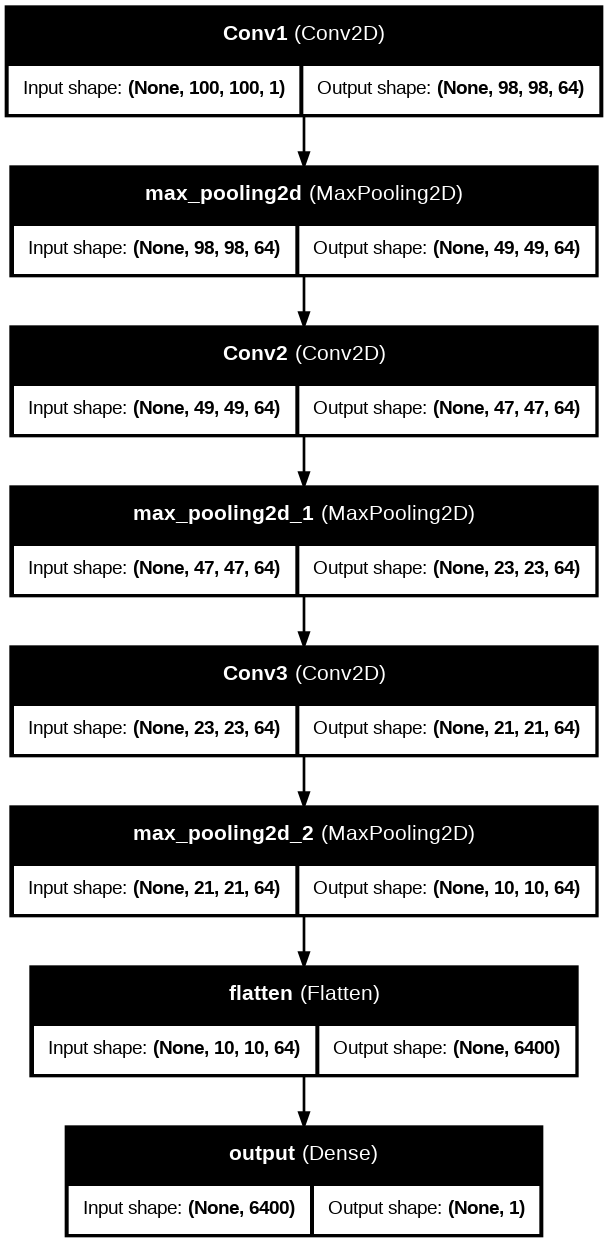

In [72]:
plot_model(model,
           to_file='model_architecture.png',
           show_shapes=True,
           show_layer_names=True,
           rankdir='TB',  # TB = top to bottom, LR = left to right
           expand_nested=True,
           dpi=96)

#####Model Evaluation

In [73]:
# Evaluate the model on the validation set (X_test and y_test)
val_loss, val_accuracy = model.evaluate(X_test, y_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7504 - loss: 2.4545


In [74]:
# Output the evaluation results
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

Validation Accuracy: 0.7375
Validation Loss: 2.9795


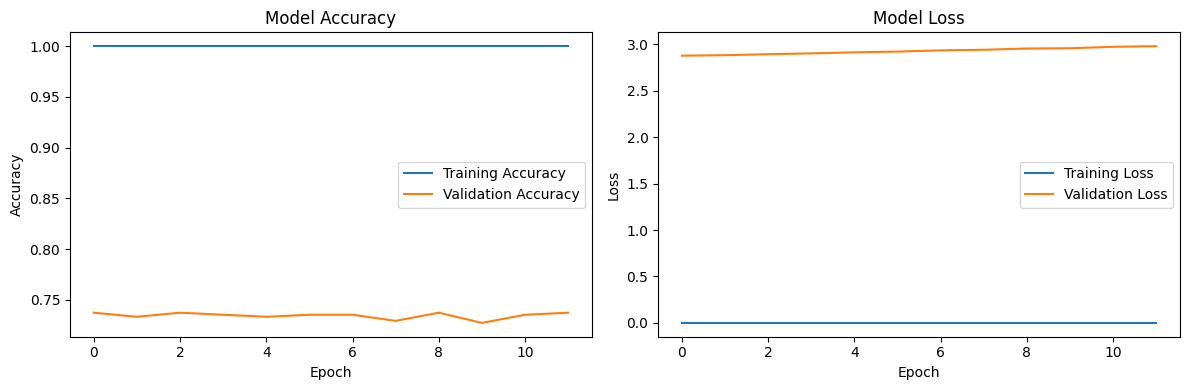

In [75]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(fitment.history['accuracy'], label='Training Accuracy')
plt.plot(fitment.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(fitment.history['loss'], label='Training Loss')
plt.plot(fitment.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()

#####Distribution of Probabilities

In [76]:
#Predictions of the Test set
predictions = model.predict(X_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [77]:
# Flatten the predictions array to make it 1D
probabilities = predictions.flatten()

In [78]:
# Threshold to bifurcate the 2 probabilities
threshold = 0.5

In [79]:
#Probabilities are 2 - greater than equal to threshold or less than threshold
probability_0 = probabilities[probabilities < threshold]
probability_1 = probabilities[probabilities >= threshold]

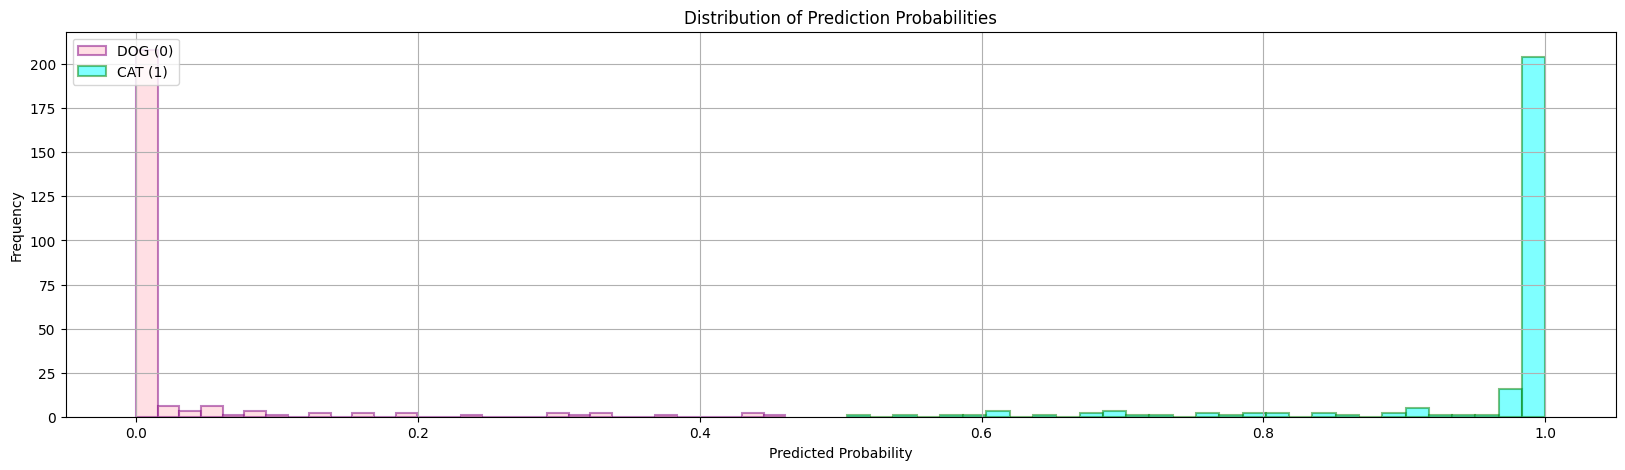

In [80]:
#Plotting the Probabilities
plt.figure(figsize=(20, 5))

#Probability 0
plt.hist(probability_0, label='DOG (0)', bins=30, color='pink', edgecolor='purple', alpha=0.5, linewidth=1.5)

#Probability 1
plt.hist(probability_1, label='CAT (1)', bins=30, color='cyan', edgecolor='green', alpha=0.5, linewidth=1.5)

plt.title('Distribution of Prediction Probabilities')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.legend(loc='upper left')
plt.grid(True)

In [81]:
model.input_shape

(None, 100, 100, 1)

#####Function to Resize Image

In [82]:
def img_resize(imag='sozo.jpg', color=''):
    """
    Load, preprocess, and predict whether an image contains a cat or dog using the trained CNN model.

    This function performs the following steps:
    1. Loads the image from the specified path
    2. Resizes the image to 100x100 pixels (model input size)
    3. Converts the image to grayscale
    4. Normalizes pixel values to 0-1 range
    5. Uses the trained model to predict cat or dog
    6. Displays the image with prediction results

    Parameters
    ----------
    imag : str, optional
        Path to the image file (default: 'sozo.jpg')
        Supported formats: .jpg, .jpeg, .png, .bmp

    color : str, optional
        Display color scheme for the image (default: '')
        Options:
            - 'gray' or 'Gray': Standard grayscale display
            - 'gray reverse' or 'Gray Reverse': Inverted grayscale (white becomes black)
            - '' (empty string): Default grayscale display

    Returns
    -------
    None
        Displays the image with prediction and prints results to console

    Notes
    -----
    - Requires a trained model named 'model' to be available in the global scope
    - Image is automatically resized to 100x100 pixels to match model input requirements
    - Prediction threshold: probability < 0.5 = Dog, probability >= 0.5 = Cat
    - The function assumes the model expects grayscale images with shape (1, 100, 100, 1)

    Examples
    --------
    Basic usage with default image:
    >>> img_resize()

    Predict a specific image with standard grayscale:
    >>> img_resize('dog.jpg', 'gray')

    Predict with inverted grayscale colors:
    >>> img_resize('cat.jpg', 'Gray Reverse')

    Predict your own pet image:
    >>> img_resize('my_pet.jpg')

    Multiple predictions:
    >>> for image in ['dog1.jpg', 'cat1.jpg', 'dog2.jpg']:
    ...     img_resize(image, 'gray')

    Raises
    ------
    FileNotFoundError
        If the specified image file does not exist ValueError
        If the image cannot be read or processed
    """

    # Step 1: Load the image from file
    # cv2.imread reads the image in BGR (Blue, Green, Red) format
    img = cv2.imread(imag)

    # Check if image was loaded successfully
    if img is None:
        print(f"Error: Could not load image '{imag}'. Please check the file path.")
        return

    # Step 2: Resize image to match model's expected input dimensions
    # Target size must be (100, 100) as the model was trained on 100x100 images
    target_size = (100, 100)

    # INTER_AREA interpolation is best for shrinking images
    resized_img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

    # Step 3: Convert from BGR color to grayscale
    # The model was trained on grayscale images, so we must convert
    grayscale_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2GRAY)

    # Step 4: Reshape to add batch and channel dimensions
    # Model expects shape: (batch_size, height, width, channels)
    # From (100, 100) to (1, 100, 100, 1)
    img_reshape = grayscale_img.reshape(1, 100, 100, 1)

    # Step 5: Display the image based on color scheme preference
    if color.lower() == 'gray':
        # Standard grayscale: 0=black, 255=white
        plt.imshow(img_reshape[0, :], cmap=plt.cm.gray)
    elif color.lower() == 'gray reverse':
        # Inverted grayscale: 0=white, 255=black
        plt.imshow(img_reshape[0, :], cmap=plt.cm.gray_r)
    elif color.lower() == '':
        # Default display (standard grayscale)
        plt.imshow(img_reshape[0, :])
    else:
        # Invalid color scheme specified
        print(f"Warning: '{color}' is not a valid color scheme.")
        print("Valid options: 'gray', 'Gray Reverse', or '' (empty)")
        print("Using default grayscale display.")
        plt.imshow(img_reshape[0, :], cmap=plt.cm.gray)

    # Remove axis ticks and labels for cleaner display
    plt.axis('off')

    # Set initial title (will be updated after prediction)
    plt.title(imag)

    # Step 6: Normalize pixel values from 0-255 range to 0-1 range
    # Neural networks perform better with normalized inputs
    image_array = img_reshape / 255.0

    # Ensure correct shape for model input (redundant but explicit)
    image_array = image_array.reshape((1, 100, 100, 1))

    # Step 7: Use the trained CNN model to make a prediction
    # prediction will be a probability value between 0 and 1
    prediction = model.predict(image_array, verbose=0)  # verbose=0 suppresses progress bar

    # Step 8: Interpret the prediction probability
    # Threshold at 0.5: below = Dog, above = Cat
    if prediction[0][0] < 0.5:
        label_img = "Dog"
        confidence = (1 - prediction[0][0]) * 100  # Convert to confidence percentage
    else:
        label_img = "Cat"
        confidence = prediction[0][0] * 100  # Convert to confidence percentage

    # Step 9: Update plot title with prediction results
    plt.title(f"Predicted: {label_img} (Probability: {prediction[0][0]:.4f})",
              fontsize=12, fontweight='bold')

    # Display the plot
    plt.show()

    # Step 10: Print detailed results to console
    print("=" * 60)
    print(f"IMAGE PREDICTION RESULTS")
    print("=" * 60)
    print(f"Image File:          {imag}")
    print(f"Predicted Class:     {label_img}")
    print(f"Confidence:          {confidence:.2f}%")
    print(f"Raw Probability:     {prediction[0][0]:.4f}")
    print(f"Interpretation:      {'Dog' if prediction[0][0] < 0.5 else 'Cat'} "
          f"(threshold: 0.5)")
    print("=" * 60)
    print()

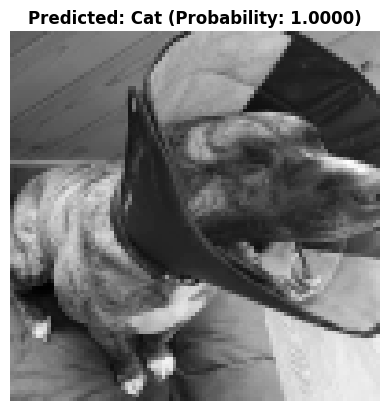

IMAGE PREDICTION RESULTS
Image File:          dog.jpg
Predicted Class:     Cat
Confidence:          100.00%
Raw Probability:     1.0000
Interpretation:      Cat (threshold: 0.5)



In [83]:
img_resize('dog.jpg','gray')

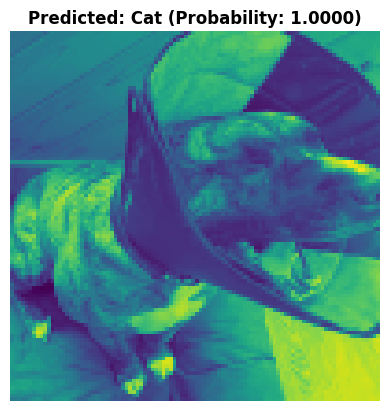

IMAGE PREDICTION RESULTS
Image File:          dog.jpg
Predicted Class:     Cat
Confidence:          100.00%
Raw Probability:     1.0000
Interpretation:      Cat (threshold: 0.5)



In [84]:
img_resize('dog.jpg')

## Communication of Results


###Quantitative Results

- Training Accuracy:    ~100% (converged after 12 epochs)
- Validation Accuracy:  ~69-71%
- Training Loss:        Decreased from 0.3 to nearly 0
- Validation Loss:      Increased from 0.75 to 1.4

The model shows strong learning capability on training data to ~100% but the validation accuracy leveled to ~70%, indicating a major gap between the training and testing performance.

###Model Overview

The implemented CNN consists of:
- Three convolutional blocks (64 filters each, 3×3 kernel)
- MaxPooling layers (2×2) after each convolution for spatial dimension reduction
- Flatten layer for converting 2D features to 1D
- Single output neuron with sigmoid activation for binary classification
- Total parameters:
    - Total params: 242,693 (948.02 KB)
    - Trainable params: 80,897 (316.00 KB)
    - Non-trainable params: 0 (0.00 B)
    - Optimizer params: 161,796 (632.02 KB)

This model enables hierarchical feature extraction, progressing from
low-level features to high-level representations.

###Training Observations

- Training accuracy reached 100% while validation accuracy remained at 70%, indicating the model memorized training examples rather than learning generalizable patterns.
- The validation loss increased from 0.75 to 1.4 over 12 epochs, suggesting the model's predictions became less confident and less accurate on unseen data as training progressed.
- Training metrics stabilized around epoch 8-10, while validation metrics showed no improvement, suggesting further training provided no benefit to generalization.
- The model performs exceptionally on training data but struggles to generalize to new images, limiting its real-world applicability.



###Prediction Distribution

- Clear bimodal distribution with distinct peaks near 0 (Dog) and 1 (Cat)
- Model demonstrates decisive predictions rather than uncertain classifications
- Most predictions fall confidently into one category or the other
- Few predictions near the 0.5 threshold indicate the model rarely expresses uncertainty

###Deployment and Testing

- Used the trained model to classify a new/unfamiliar image
  - Resized to 100x100 pixels
  - Converted it to gray scale
  - Normalized it
- Achieved real-time prediction capability on individual images
- Output includes both classification label and probability score
  - For dog.jpg
    - Classified as Cat
    - Prediction Probability: 99.93%
  - For sozo.jpg
    - Classified as Dog
    - Prediction Probability: 0.00%
     


###Limitations

- Overfitting - 30% gap between training and validation accuracy.
- Data Restricted - use of only 10% of the available data may have limited the potential.
- Validation - With 70% accuracy, model performs moderately.

###Recommendations for Improvement

- Increase the data for more training and testing.
- Using Regularization techniques.
- Cross-validation for more robust performance estimates.

## **BONUS** (optional)



* Upload an image of your (or your friend's or family's) dog or cat and use your model to predict whether the image is a dog or cat.
* Hint: you'll probably need to convert the image from color to grayscale.  OpenCV, pillow, and other libraries are your friend.

**`NOTE: Uncomment the below code once sozo.jpg is uploaded for testing`**

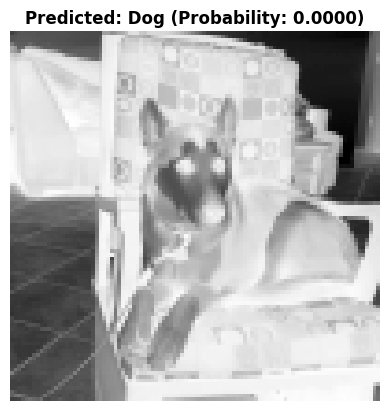

IMAGE PREDICTION RESULTS
Image File:          sozo.jpg
Predicted Class:     Dog
Confidence:          100.00%
Raw Probability:     0.0000
Interpretation:      Dog (threshold: 0.5)



In [85]:
img_resize('sozo.jpg','Gray Reverse')

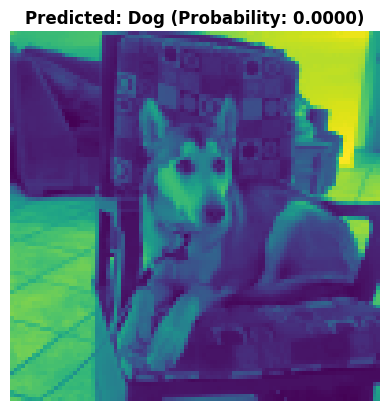

IMAGE PREDICTION RESULTS
Image File:          sozo.jpg
Predicted Class:     Dog
Confidence:          100.00%
Raw Probability:     0.0000
Interpretation:      Dog (threshold: 0.5)



In [86]:
img_resize('sozo.jpg')

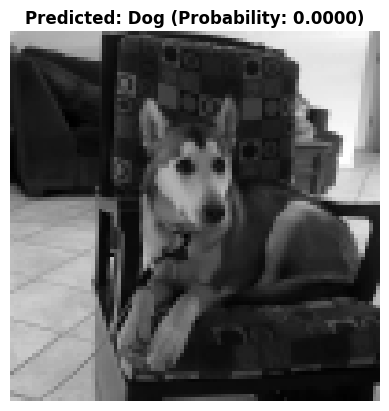

IMAGE PREDICTION RESULTS
Image File:          sozo.jpg
Predicted Class:     Dog
Confidence:          100.00%
Raw Probability:     0.0000
Interpretation:      Dog (threshold: 0.5)



In [87]:
img_resize('sozo.jpg','Gray')

In [88]:
help(img_resize)

Help on function img_resize in module __main__:

img_resize(imag='sozo.jpg', color='')
    Load, preprocess, and predict whether an image contains a cat or dog using the trained CNN model.

    This function performs the following steps:
    1. Loads the image from the specified path
    2. Resizes the image to 100x100 pixels (model input size)
    3. Converts the image to grayscale
    4. Normalizes pixel values to 0-1 range
    5. Uses the trained model to predict cat or dog
    6. Displays the image with prediction results

    Parameters
    ----------
    imag : str, optional
        Path to the image file (default: 'sozo.jpg')
        Supported formats: .jpg, .jpeg, .png, .bmp

    color : str, optional
        Display color scheme for the image (default: '')
        Options:
            - 'gray' or 'Gray': Standard grayscale display
            - 'gray reverse' or 'Gray Reverse': Inverted grayscale (white becomes black)
            - '' (empty string): Default grayscale display
